# **Group 2**
## A Prediction Model for Determining the Optimum Planting Calendar in India



# Students: 

*   Caroline Akinyi - 149457
*   Khidir Ramadhan - 083303
*   Kigen Nderito - 151148
*   Maria Ogamba - 100060
*   Rosemary Kanyoro - 149765
*   Simon Macharia - 151310








# Introduction

## Business Understanding


### Business Objective:

The 2030 Agenda for Sustainable Development adopted in 2015 by all member states of the United Nations has 17 Sustainable Development Goals (SDGs).

This analysis focused on SDG 2 : "To end hunger, achieve food security and improved nutrition and promote sustainable agriculture". A key target under the SDG is by 2030 to ensure sustainable food production systems and implement resilient agricultural practices that increase productivity and production.

The objective is to improve agricultural productivity by analysing data on rainfall and crop yields to develop a optimal farming season calendar that improves productivity.
This can be used in the fight to end hunger, achieve food security, and promote sustainable agriculture in accordance with SDG 2.

### Problem statement
In the past, farmers have benefited from traditional crop yield estimations and planting calendars for reliable harvests. However, due to global warming and climate change, traditional methods are becoming less reliable. 

### Research Questions
*   What are the main factors influencing the yields of different crops?
*   Can a machine learning algorithm be used to optimise the planting calendar to maximize yields?
*   Can historical rainfall data be used to forecast future rainfall patterns?

### Data Analysis
The type of analysis that was conducted was: 
*   Predictive analysis 
*   Time series analysis

### Scope of Work
This study will investigate the possibilities of predicting crop yields. We will analyse long-term rainfall data in india, the crop production and relate it to the different states in India. A predictive model will be created and tested the best times of the year to grow various crops. 

The deliverable is to create a prediction model that factors in rainfall, state,crop yields and seasons

## Data Understanding

### The context
Different crops have different rainfall requirements and do well in different regions. To maximize the farmers’ yields, one needs to understand the best conditions for planting for various crops and which regions are suitable for their production. This is why we will use historical data to understand which seasons and regions produced high yields and build a model to predict yield based on the data.

### Data availability & Initial data collection
We checked various online open access data repositories to get weather and crop yield datasets. There are several weather datasets available online. However, getting data on Rainfall in Kenya proved to be challenging therefore we settled on working with the dataset from India and develop a model that can be extrapolated in other geographical scope.


### Information Needed
*   Rainfall data for a given time period and for a specific region
*   Crop data per region 
*   Area and production information per region 

### Data Exploration and Characteristics
There were 2 datasets Crop data and rainfall data.
For Crop data:
*   The data covers the below 33 states in India
*   Has 246,091 rows and 7 columns.
*   3730 missing values; 1.5% of the total data.
*   Contains the yield of 124 crops from the years 2000 to 2015.
*   There are various data types including floats, objects and integers.

### For rainfall data:
*  The data covers the below 36 subdivisions in India
*  Has 4, 166 rows and 19 columns.
*  134 missing values; 3.2% of the total data.
*  Data grouped per month, Jan-Feb, Mar-May, Jun-Sep, Oct-Dec for the period between 1901 and 2015.
*  All columns are floats except the Subdivision column

The regions covered in the 2 datasets had some differences especially where some states were combined into subdivisions in the rainfall data.This and the other issues will be dealt with during data cleaning.


#Table of Contents

[Introduction](#Intro)
1. [Exploratory Data Analysis](#eda)  
    1.1 [Crop Data EDA](#cropEDA)  
    1.2 [Rainfall Data EDA](#rainfallEDA)  
2. [Data Cleaning and Preparation](#cleaning)  
    2.1 [Crop Data Cleaning and Preparation](#cropcleaning)  
    2.2 [Rainfall Data Cleaning and Preparation](#raincleaning)  
    2.3 [Merging Production and Rainfall Data](#merging)   
3. [Crop Modelling](#modelling)
4.  [Visualization and presentation](#vis2)   
    4.1 [Predicted Yield Per Season](#predictedyield)  
    4.2 [Conclusion](#conclusion)


####   Import the necessary libraries

In [109]:

# data analysis and wrangling
import numpy as np
import pandas as pd

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn

#Machine learining
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Use updated seaborn style
plt.style.use('seaborn-v0_8')

# Custom colors
deep_green = '#006838'
earth_red = '#C4521E'

## 1. Exploratory Data Analysis <a name="eda"></a>

### 1.1 Crop Data EDA <a name="cropEDA"></a>

In [110]:
''' 
 The crop production dataset in India was retrieved from Kaggle
 It provides several years worth of information on crop production in India
 https://www.kaggle.com/datasets/abhinand05/crop-production-in-india
'''

# Reading the Crops data into a Pandas DataFrame
yields = pd.read_csv("https://raw.githubusercontent.com/khidwiser/pds_group_project/main/crops_india.csv")

In [111]:
# Preview  the first 5 rows to gain an understanding of the data
yields.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [112]:
# Number of states, seasons and crops in the data 
yields[['State_Name', 'Season', 'Crop']].nunique()

State_Name     33
Season          6
Crop          124
dtype: int64

In [113]:
# Years the data was collected
yields['Crop_Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2010, 1997, 1998, 1999,
       2007, 2008, 2009, 2011, 2012, 2013, 2014, 2015])

In [114]:
# Check the data info of the variables
yields.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [115]:
# Statistical summary of the numerical attribures
yields.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [116]:
# Counts for each season
yields.Season.value_counts()

Season
Kharif         95951
Rabi           66987
Whole Year     57305
Summer         14841
Winter          6058
Autumn          4949
Name: count, dtype: int64

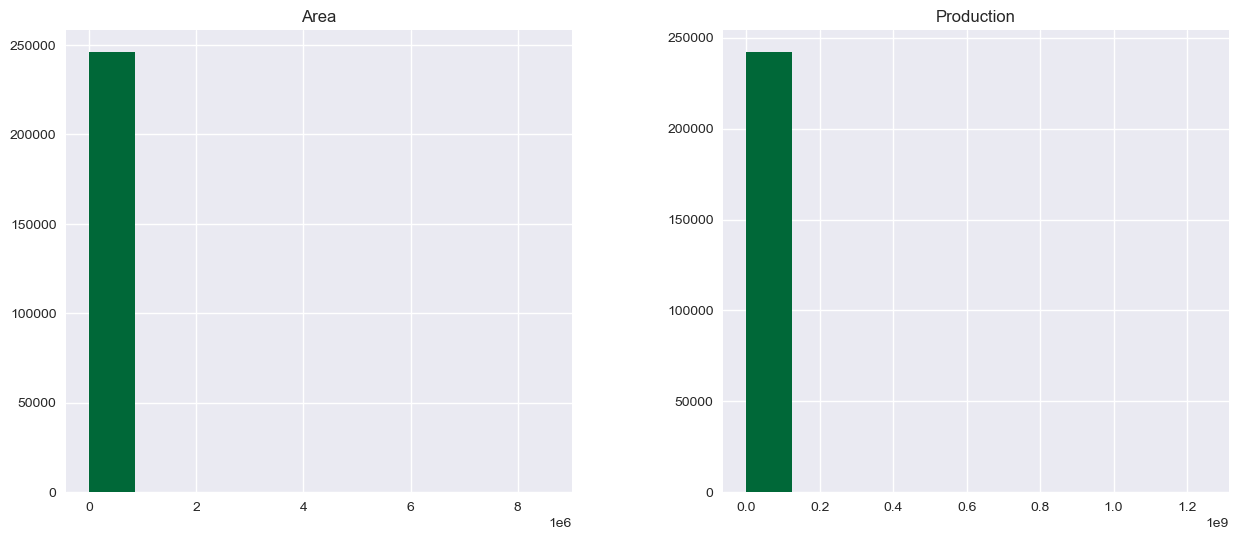

In [117]:


#Visualise the distribution of the Area and Production Variables using histograms
yields[['Area', 'Production']].hist(figsize=(15,6), color=deep_green)
plt.show()

In [118]:
# Skewness and kurtosis of Area of production
print(f"Skewness of Area of Production: {round(yields['Area'].skew(), 2)}")
print(f"Kurtosis of Area of Production: {round(yields['Area'].kurt(), 2)}")

Skewness of Area of Production: 48.0
Kurtosis of Area of Production: 5568.38


In [119]:
# Skewness and kurtosis of production
print(f"Skewness of Production: {round(yields['Production'].skew(), 2)}")
print(f"Kurtosis of Production: {round(yields['Production'].kurt(), 2)}")

Skewness of Production: 40.74
Kurtosis of Production: 1882.11


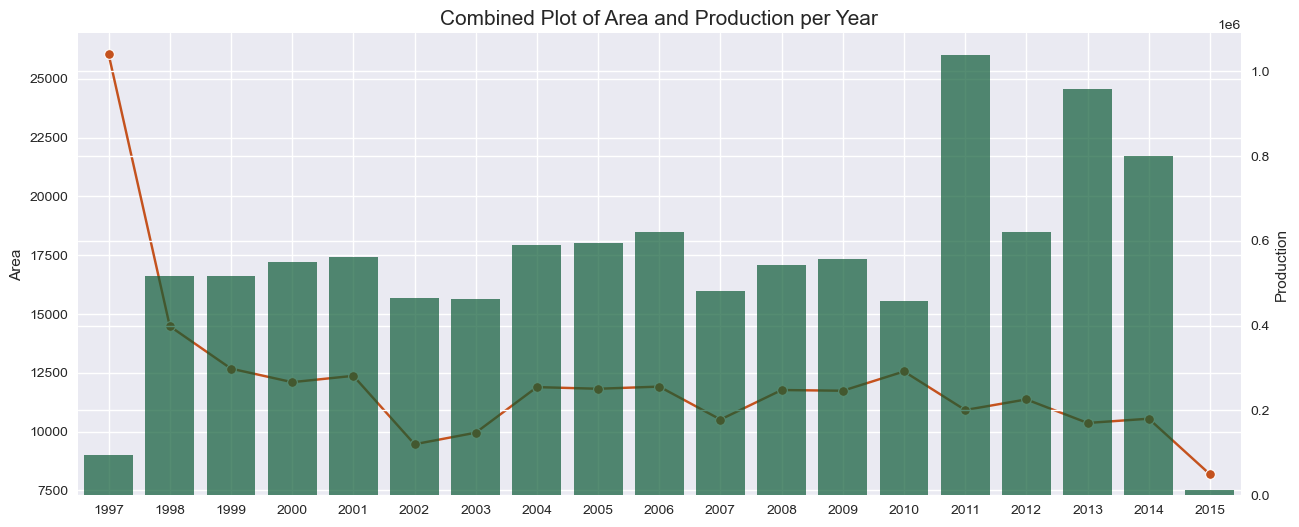

In [120]:
''' 
Visualise a comparison  of Area and Production per year 
To seek to understand the relationship between the two variables
'''

# Subset and group a protion of the dataset
yields_per_year = yields.groupby(['Crop_Year']).agg({'Area': 'mean', 'Production': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(15,6))

# Lineplot of the annual Area cultivated
sns.lineplot(data = yields_per_year['Area'], marker='o', sort = False, ax=ax1, color=earth_red, legend = True)
ax2 = ax1.twinx()

#Barplot of the Annual Crops produced
sns.barplot(data = yields_per_year, x='Crop_Year', y='Production', alpha=0.7, ax=ax2, color=deep_green)
plt.title("Combined Plot of Area and Production per Year", size =15)
# plt.xlabel('Year')
plt.show();

Area shows a reducing trend, while production is increasinfg and peaked in 2011. This may indicate an improvement in the efficiency to gain a higher yield per Ares cultivated

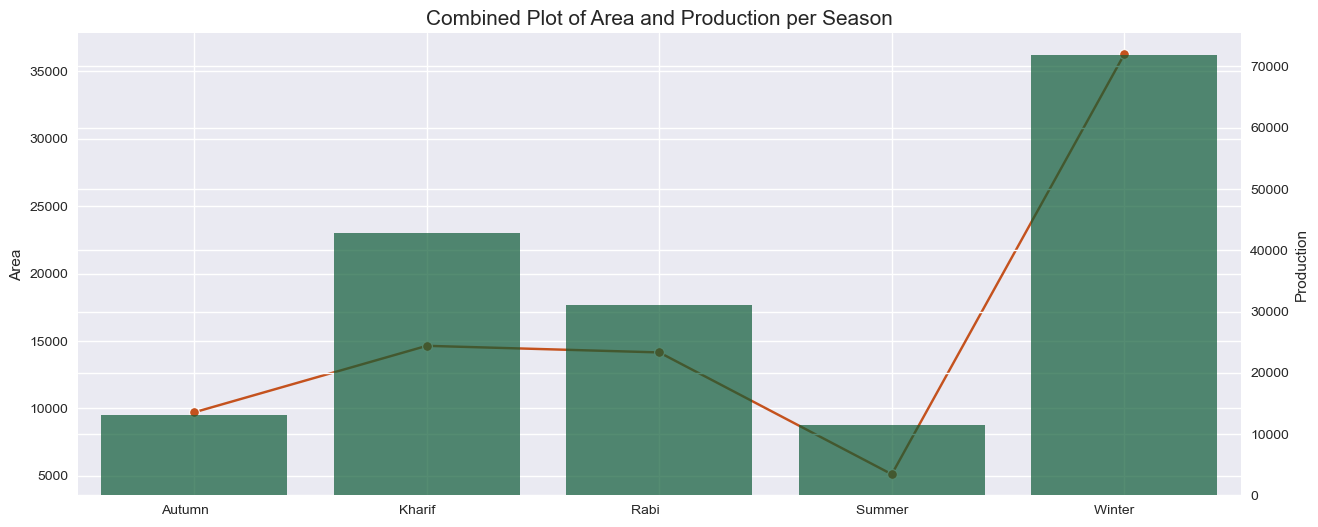

In [121]:
'''
To further understand the relationship between the Area and Production 
Visualise a comparison  of the two variables per season 
'''
# Filter yields for individual seasons
yields_per_season = yields[yields["Season"].str.contains('Year') == False]

# Group by crop production per season
yields_per_season = yields_per_season.groupby(['Season']).agg({'Area': 'mean', 'Production': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(15,6))

# Lineplot of the seasonal Area cultivated
sns.lineplot(data = yields_per_season['Area'], marker='o', sort = False, ax=ax1, color=earth_red)
ax2 = ax1.twinx()

# barplot of the Seasonal Area cultivated
sns.barplot(data = yields_per_season, x='Season', y='Production', alpha=0.7, ax=ax2, color=deep_green)

plt.title("Combined Plot of Area and Production per Season", size =15)
plt.xlabel('Season')
plt.show()

The winter season is the most productive season overall while the summer season is the least productive.

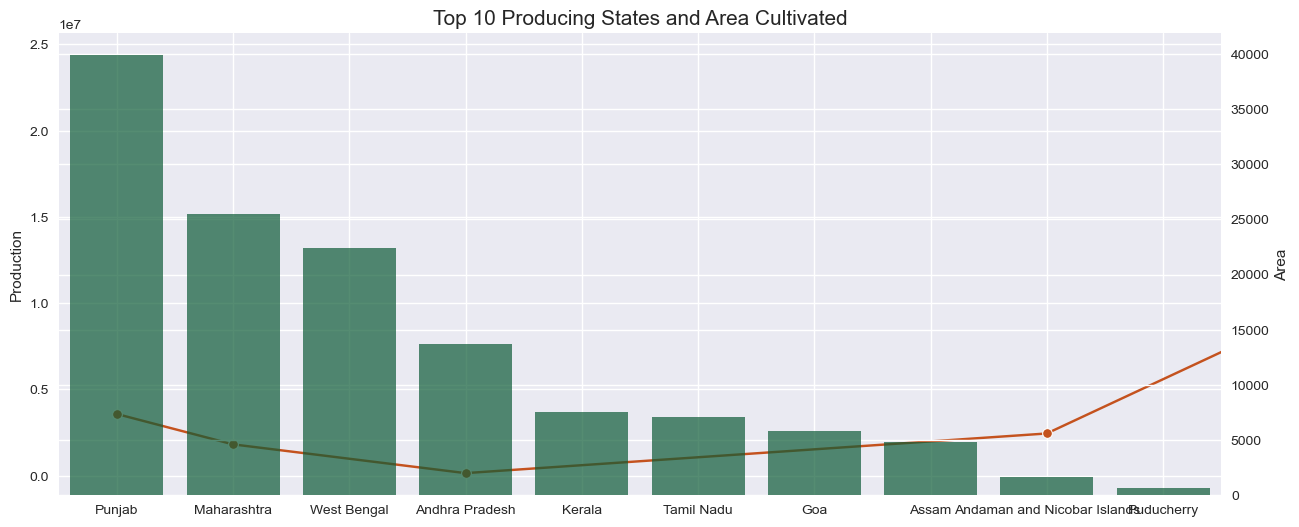

In [122]:
'''
Comparison of the production and Area cultivated per State 
and visualise the top 10 states by Production
'''

# Group the data by State and aggregate the Area & Production as their mean
yields_per_state = yields.groupby(['State_Name']).agg({'Area': 'mean', 'Production': 'mean'}).reset_index()

#Select the 10 largest states by Production
yields_per_state_t10 = yields_per_state.nlargest(10, 'Production').sort_values('Area', ascending=False)

#Initialise the visualisation
fig, ax1 = plt.subplots(figsize=(15,6))

#Lineplot of Production per State
sns.lineplot(data = yields_per_state_t10['Production'], marker='o', sort = True, ax=ax1, color=earth_red)
ax2 = ax1.twinx()

#Barplot of Area per state
sns.barplot(data = yields_per_state_t10, x='State_Name', y='Area', alpha=0.7, ax=ax2, color=deep_green)

plt.title("Top 10 Producing States and Area Cultivated", size =15)

plt.show()

Punjab is the State with the highest production followed by Maharashtra and Puducherry is 10th 

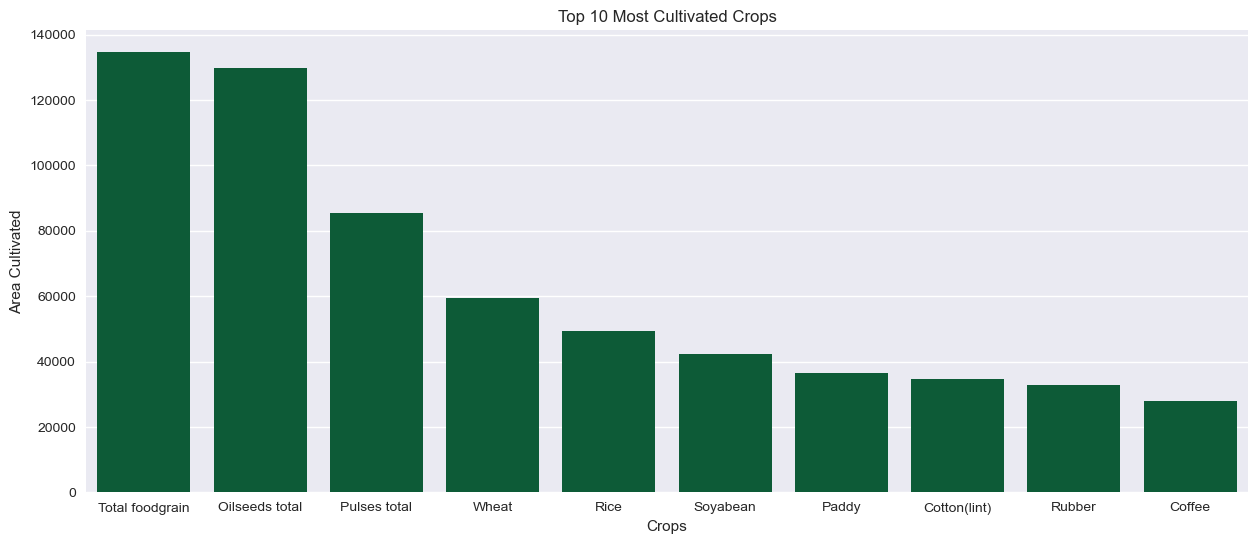

In [123]:
'''
Most cultivated crops
'''


#Group by Crops and aggrefate the Area and production variables then filter the top 10
yields_per_crop = yields.groupby(['Crop']).agg({'Area': 'mean', 'Production': 'mean'}).reset_index()
yields_per_crop_t10 = yields_per_crop.nlargest(10, 'Area').sort_values('Area', ascending=False)

fig, ax =plt.subplots(figsize=(15, 6))
sns.barplot(data=yields_per_crop_t10, x='Crop', y='Area', color=deep_green)\
.set(title='Top 10 Most Cultivated Crops', xlabel='Crops', ylabel='Area Cultivated')
plt.show()

The most cultivated crops are the categories of Food grains then oilseeds. Individually the top 5 are Wheat, Rice, Soybean, Paddy rice and Cotton

### 1.2 Rainfall Data EDA <a name="rainfallEDA"></a>

In [124]:
''' 
 The rainfall dataset in India was retrieved from Kaggle
The data set contains monthly rainfall detail of 36 meteorological sub-divisions of India.
https://www.kaggle.com/datasets/rajanand/rainfall-in-india
'''

# Read rainfall data
rainfall = pd.read_csv("https://raw.githubusercontent.com/Akinyi-Carol/MSc-DSA/main/PDS/rainfall_india.csv")

In [125]:
# Number of rows and columns in the rainfall data
rainfall.shape

(4116, 19)

In [126]:
# First five rows
rainfall.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [127]:
# Rainfall info
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4116 non-null   object 
 1   YEAR         4116 non-null   int64  
 2   JAN          4112 non-null   float64
 3   FEB          4113 non-null   float64
 4   MAR          4110 non-null   float64
 5   APR          4112 non-null   float64
 6   MAY          4113 non-null   float64
 7   JUN          4111 non-null   float64
 8   JUL          4109 non-null   float64
 9   AUG          4112 non-null   float64
 10  SEP          4110 non-null   float64
 11  OCT          4109 non-null   float64
 12  NOV          4105 non-null   float64
 13  DEC          4106 non-null   float64
 14  ANNUAL       4090 non-null   float64
 15  Jan-Feb      4110 non-null   float64
 16  Mar-May      4107 non-null   float64
 17  Jun-Sep      4106 non-null   float64
 18  Oct-Dec      4103 non-null   float64
dtypes: flo

In [128]:
# Statistical analysis of the numeric columns
rainfall.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
count,4116.000000,4112.000000,4113.000000,4110.000000,4112.000000,4113.000000,4111.000000,4109.000000,4112.000000,4110.000000,4109.000000,4105.000000,4106.000000,4090.000000,4110.000000,4107.000000,4106.000000,4103.000000
mean,1958.218659,18.957320,21.805325,27.359197,43.127432,85.745417,230.234444,347.214334,290.263497,197.361922,95.507009,39.866163,18.870580,1411.008900,40.747786,155.901753,1064.724769,154.100487
std,33.140898,33.585371,35.909488,46.959424,67.831168,123.234904,234.710758,269.539667,188.770477,135.408345,99.519134,68.685410,42.369611,903.846565,59.308277,201.316965,707.741531,166.942660
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,62.300000,0.000000,0.000000,57.400000,0.000000
25%,1930.000000,0.600000,0.600000,1.000000,3.000000,8.600000,70.350000,175.600000,155.975000,100.525000,14.600000,0.700000,0.100000,804.500000,4.100000,24.050000,573.850000,34.200000
50%,1958.000000,6.000000,6.700000,7.800000,15.700000,36.600000,138.700000,284.800000,259.400000,173.900000,65.200000,9.500000,3.000000,1121.300000,19.200000,74.800000,881.100000,98.200000
75%,1987.000000,22.200000,26.800000,31.300000,49.950000,97.200000,305.150000,418.400000,377.800000,265.800000,148.400000,46.100000,17.500000,1644.775000,50.375000,196.950000,1288.175000,213.500000
max,2015.000000,583.700000,403.500000,605.600000,595.100000,1168.600000,1609.900000,2362.800000,1664.600000,1222.000000,948.300000,648.900000,617.500000,6331.100000,699.500000,1745.800000,4536.900000,1252.500000


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18428\2362834831.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=rainfall, x='YEAR', y='ANNUAL', color=earth_red, ci=None)\


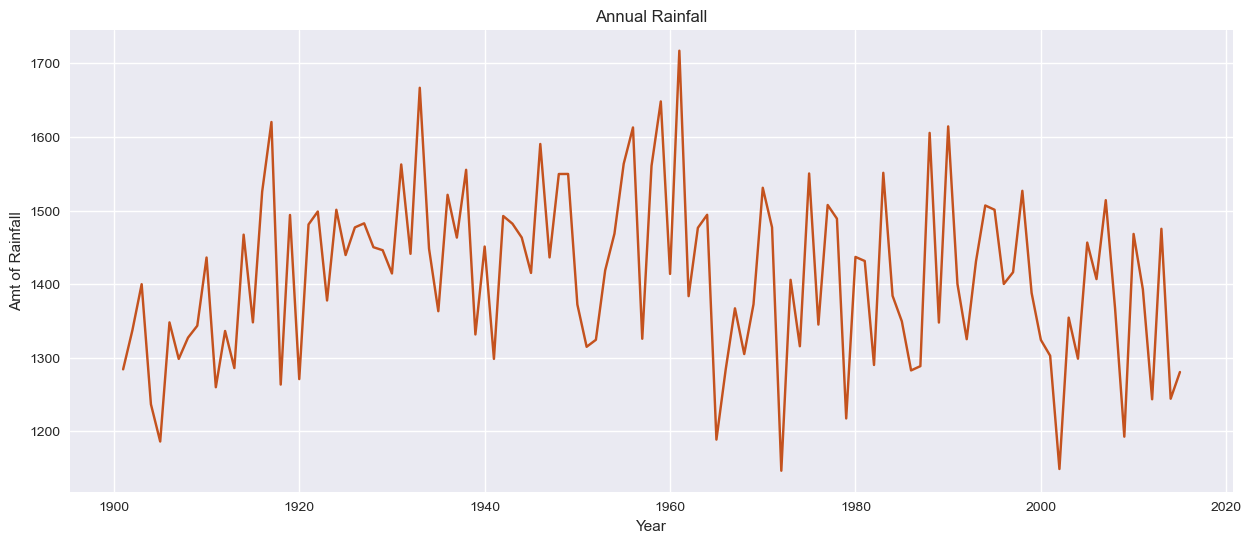

In [129]:
# Visualise the Annual Rainfall
fig, ax =plt.subplots(figsize=(15, 6))
sns.lineplot(data=rainfall, x='YEAR', y='ANNUAL', color=earth_red, ci=None)\
.set(title='Annual Rainfall', xlabel='Year', ylabel='Amt of Rainfall')
plt.show()

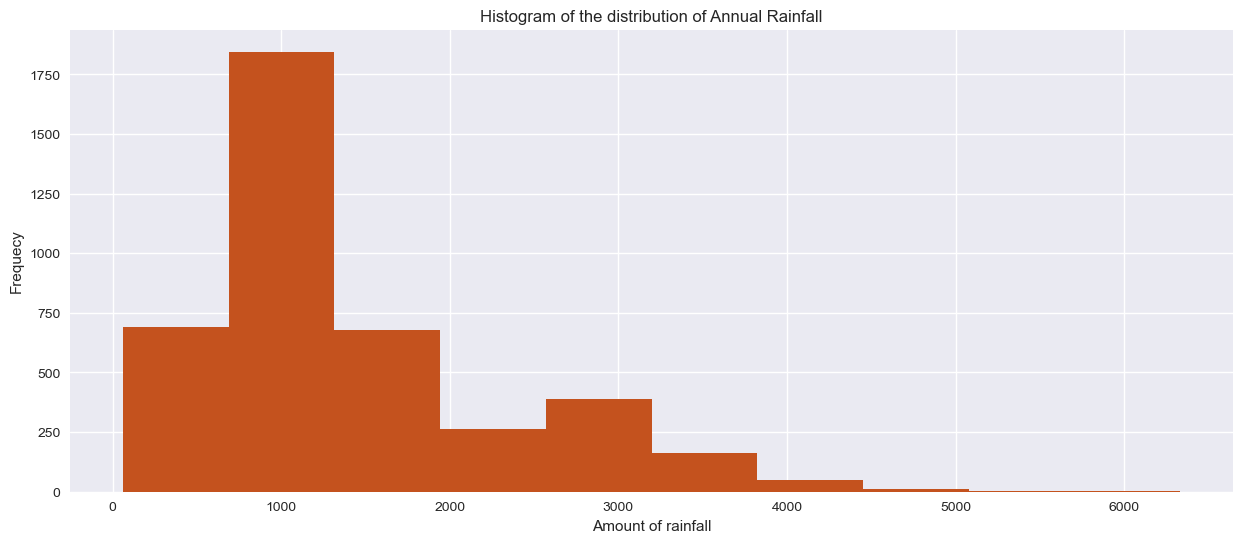

In [130]:
# Visualise the distribution of the annual rainfall  using a Histogram
rainfall['ANNUAL'].hist(figsize=(15,6), color=earth_red)\
.set(title='Histogram of the distribution of Annual Rainfall', xlabel='Amount of rainfall', ylabel='Frequecy')
plt.show()

Annual rainfall is assymetrically distributed and skewed to the right ie positively skewed 

In [131]:
# Investigate the numerical values of Skewness and kurtosis of Area of production
print(f"Skewness of Area of Annual Rainfall: {round(rainfall['ANNUAL'].skew(), 2)}")
print(f"Kurtosis of Area of Annual Rainfall: {round(rainfall['ANNUAL'].kurt(), 2)}")

Skewness of Area of Annual Rainfall: 1.32
Kurtosis of Area of Annual Rainfall: 1.39


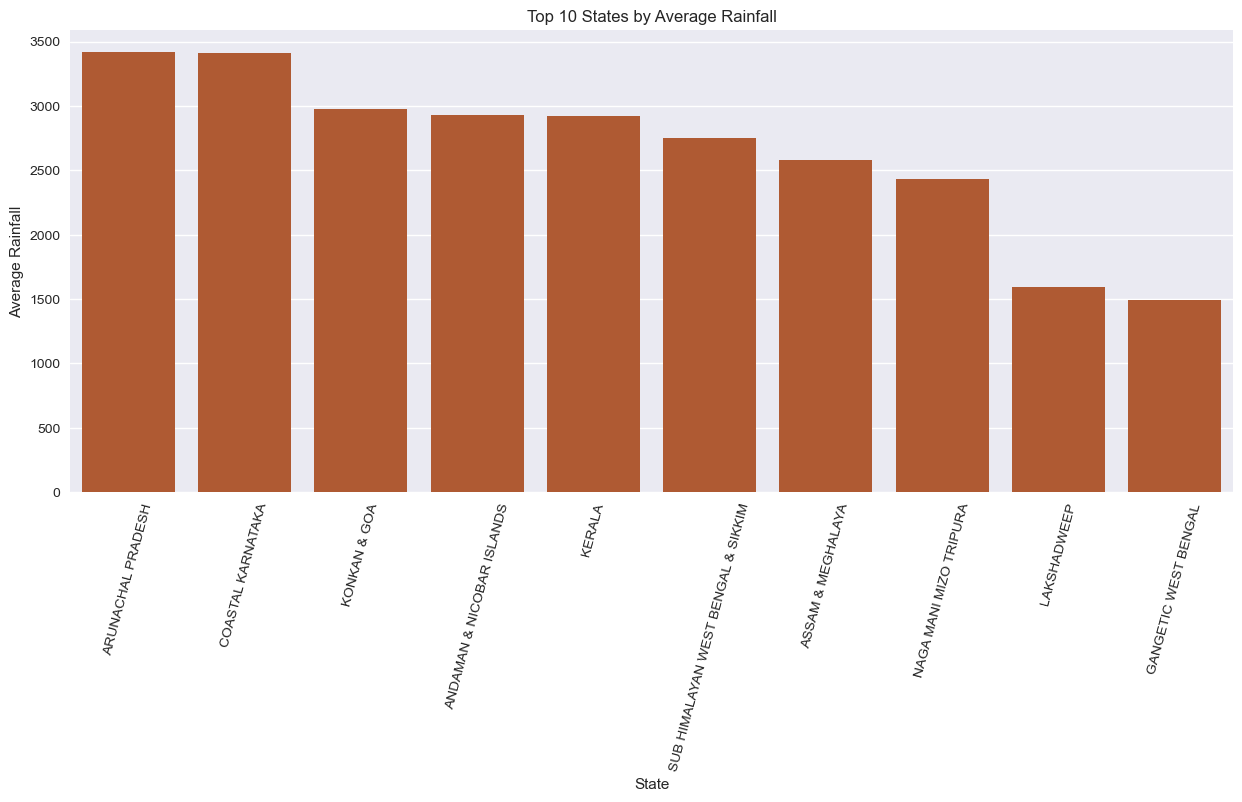

In [132]:
# Top 10 States for rainfall
rainfall_per_state = rainfall.groupby(['SUBDIVISION']).agg({'ANNUAL': 'mean'}).reset_index()
rainfall_per_state_t10 = rainfall_per_state.nlargest(10, 'ANNUAL')

fig, ax =plt.subplots(figsize=(15, 6))
sns.barplot(data=rainfall_per_state_t10, x='SUBDIVISION', y='ANNUAL', color=earth_red)\
.set(title='Top 10 States by Average Rainfall', xlabel='State', ylabel='Average Rainfall')
plt.xticks(rotation=75)
plt.show()

The state that has recieved the highest annual average rainfall is Arunachal Pradesh followed closely by Coastal Karnakata, then KinKan & Goa.

## 2. Data Cleaning and Preparation<a name="cleaning"></a>

### 2.1. Crops Data Cleaning and Preparation<a name="cropcleaning"></a>

In [133]:
yields.head(3)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0


In [134]:
# Drop district name
yields = yields.drop(['District_Name'], axis=1)
yields.head(3)

,State_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,2000,Kharif,Rice,102.0,321.0


In [135]:
# Drop "Whole Year records"
yields = yields[yields['Season'] != 'Whole Year ']
yields['Season'].unique()

array(['Kharif     ', 'Autumn     ', 'Rabi       ', 'Summer     ',
       'Winter     '], dtype=object)

In [136]:
yields['prod_per_area'] = yields['Production']/yields['Area']
yields.sample(3)

,State_Name,Crop_Year,Season,Crop,Area,Production,prod_per_area
3301,Andhra Pradesh,1999,Kharif,Urad,55.0,34.0,0.618182
230584,Uttar Pradesh,2014,Kharif,Urad,1700.0,889.0,0.522941
151517,Odisha,2001,Rabi,Other Rabi pulses,2230.0,1350.0,0.605381


In [137]:
# Drop area and cumulative yields
yields = yields.drop(['Area', 'Production'], axis=1)
yields.head()

,State_Name,Crop_Year,Season,Crop,prod_per_area
0,Andaman and Nicobar Islands,2000,Kharif,Arecanut,1.594896
1,Andaman and Nicobar Islands,2000,Kharif,Other Kharif pulses,0.500000
2,Andaman and Nicobar Islands,2000,Kharif,Rice,3.147059
10,Andaman and Nicobar Islands,2001,Kharif,Arecanut,1.643541
11,Andaman and Nicobar Islands,2001,Kharif,Other Kharif pulses,0.500000


As noted earlier during the EDA, there are 124 crops in the data, we need to narrow down to fewer crops for modelling. 
For this, we'll check the percentage and count of crops and work with the top 5 crops.

In [138]:
# Get the 5 top crops by number
crops_count = yields['Crop'].value_counts()
crops_count_perc = yields['Crop'].value_counts(normalize=True)*100

print("Top 5 count\n------------------------\n{}"\
      .format(crops_count.nlargest(5)))

Top 5 count
------------------------
Crop
Rice                 14976
Maize                13707
Moong(Green Gram)    10109
Urad                  9677
Groundnut             8558
Name: count, dtype: int64


In [139]:
# Filter the data to have only the top 5 crops
top5_crops = ['Rice', 'Maize', 'Moong(Green Gram)', 'Urad', 'Sesamum']
top5_crops = yields[yields['Crop'].isin(top5_crops)]
top5_crops.sample(3)

,State_Name,Crop_Year,Season,Crop,prod_per_area
112617,Madhya Pradesh,1999,Rabi,Urad,0.250000
36145,Bihar,2011,Kharif,Moong(Green Gram),0.524017
227702,Uttar Pradesh,1999,Kharif,Moong(Green Gram),0.281250


In [140]:
# Rename Columns
top5_crops.columns = ['state', 'year', 'season', 'crop', 'yields']
print(top5_crops.shape)
print(top5_crops.head(1))

(56803, 5)
                         state  year       season  crop    yields
2  Andaman and Nicobar Islands  2000  Kharif       Rice  3.147059


In [141]:
# Transform all values to lowercase for consistency and set them to a new df called production
production = top5_crops.apply(lambda x: x.astype(str).str.lower())
production.shape

(56803, 5)

In [142]:
# Remove leading and trailing whitespace on seasons column
production['season'] = production['season'].str.strip()
production['season'].unique()

array(['kharif', 'autumn', 'rabi', 'summer', 'winter'], dtype=object)

In [143]:
# Check datatypes
production.dtypes

state     object
year      object
season    object
crop      object
yields    object
dtype: object

In [144]:
# Convert necessary attributes to floats
production.year = production.year.astype(int)
production.yields = production.yields.astype(float)

production[['year', 'yields']].dtypes

year        int64
yields    float64
dtype: object

In [145]:
# Check for missing values percentage
(production.isna().sum()/production.shape[0])*100

state     0.000000
year      0.000000
season    0.000000
crop      0.000000
yields    1.262257
dtype: float64

In [146]:
# Numerical summary of the yields column
production['yields'].describe()

count    56086.000000
mean         1.395797
std         12.320036
min          0.000000
25%          0.400000
50%          0.818182
75%          1.884770
max       1494.000000
Name: yields, dtype: float64

As the standard deviation of the yields is large and the number of missing values small, we will drop the missing values


In [147]:
# Drop missing values
production = production.dropna()

# Recheck missing values
production.isna().sum()

state     0
year      0
season    0
crop      0
yields    0
dtype: int64

In [148]:
production.shape

(56086, 5)

**Outliers in the Crops Data**

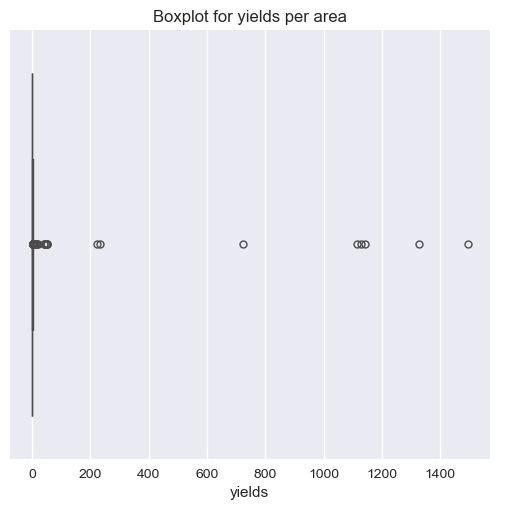

In [149]:
sns.catplot(x="yields", data=production, kind="box")
plt.title("Boxplot for yields per area")
plt.show()

There are alot of outliers especially on the upper side. To sort this, we will use the binning method to smoothen the data.

In [150]:
# Drop 6 rows with largest yields as we are going to work with 10 bins
production = production.drop(production['yields'].idxmax())
production = production.drop(production['yields'].idxmax())
production = production.drop(production['yields'].idxmax())
production = production.drop(production['yields'].idxmax())
production = production.drop(production['yields'].idxmax())
production = production.drop(production['yields'].idxmax())
production.shape

(56080, 5)

In [151]:
# Get yields and sort
yields_data = production['yields']
yields_data = yields_data.sort_values()
yields_data

69994       0.000000
19030       0.000000
134554      0.000000
70556       0.000000
66835       0.000000
             ...    
60791      50.818182
64718      52.714286
60428      53.500000
130528    223.727273
62186     235.000000
Name: yields, Length: 56080, dtype: float64

In [152]:
# Create 5 bins
bins = np.array_split(yields_data.values, 5)

In [153]:
# smoothen the bins with the mean
for bucket in bins:
    mn = bucket.mean()
    for i in range(bucket.size):
        bucket[i] = mn

In [154]:
# Reinsert smoothen values
bins = np.array(bins).flatten()
production['yields'] = bins
production['yields'].describe()

count    56080.000000
mean         1.272401
std          1.080249
min          0.211834
25%          0.462258
50%          0.839441
75%          1.645597
max          3.202874
Name: yields, dtype: float64

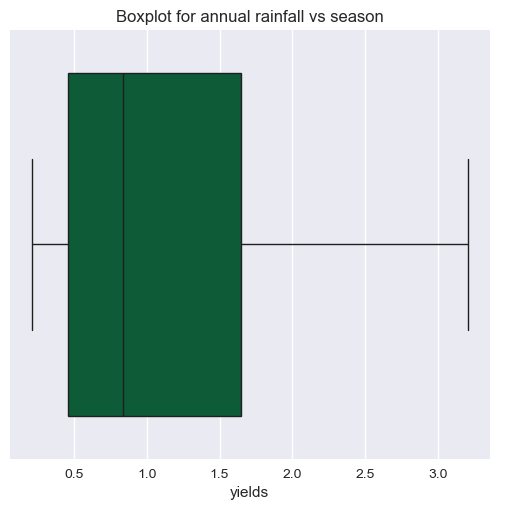

In [155]:
sns.catplot(x="yields", data=production, kind="box", color=deep_green)
plt.title("Boxplot for annual rainfall vs season")
plt.show()

## 2.2. Rainfall Data Cleaning and Preparation <a name="raincleaning"></a>

**India cropping calendar seasons**

The crops data has been grouped based on the India cropping calender:
1.  Kharif: June - October
2.  Autumn: September - Novemember
3.  Rabi: November
4.  Summer: March - May
5.  Winter: December - February

We therefore need to group the rainfall data in the same format for consistency and to perfom the analysis

In [156]:
# Add rainfall summaries of the seasons based on the months in which they occur
rainfall['kharif'] = rainfall['JUN'] + rainfall['JUL'] + rainfall['AUG'] + rainfall['SEP'] + rainfall['OCT']
rainfall['autumn'] = rainfall['SEP'] + rainfall['OCT'] + rainfall['NOV'] 
rainfall['rabi'] = rainfall['NOV'] 
rainfall['summer'] = rainfall['MAR'] + rainfall['APR'] + rainfall['MAY']
rainfall['winter'] = rainfall['DEC'] + rainfall['JAN'] + rainfall['FEB'] 
rainfall.sample(3)

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,...,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,kharif,autumn,rabi,summer,winter
866,JHARKHAND,1985,19.1,9.1,1.6,8.8,48.2,131.2,338.0,312.6,...,1240.3,28.3,58.6,998.3,155.1,1152.1,370.8,0.5,58.6,29.1
777,ORISSA,2011,3.7,16.2,4.9,58.2,75.6,210.1,199.6,358.6,...,1346.2,19.8,138.7,1167.0,20.7,1187.2,419.0,0.1,138.7,20.3
2666,MADHYA MAHARASHTRA,1945,4.2,0.0,0.0,9.8,5.2,125.6,263.7,209.0,...,793.4,4.2,15.0,730.7,43.4,767.8,175.8,6.3,15.0,4.2


In [157]:
# Drop the individual months and remain with the cropping seasons
seasons_rain = rainfall.drop(['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep','Oct-Dec'], axis=1)
seasons_rain.head()

,SUBDIVISION,YEAR,ANNUAL,kharif,autumn,rabi,summer,winter
0,ANDAMAN & NICOBAR ISLANDS,1901,3373.2,2084.8,1279.3,558.2,560.3,169.9
1,ANDAMAN & NICOBAR ISLANDS,1902,3520.7,2383.1,1222.4,359.0,458.3,320.3
2,ANDAMAN & NICOBAR ISLANDS,1903,2957.4,2055.2,804.6,284.4,236.1,381.7
3,ANDAMAN & NICOBAR ISLANDS,1904,3079.6,2199.8,1351.3,308.7,506.9,64.2
4,ANDAMAN & NICOBAR ISLANDS,1905,2566.7,1885.6,583.1,25.4,309.7,346.0


In [158]:
# New columns for the rainfall data
seasons_rain.columns = ['state', 'year', 'annual', 'kharif', 'autumn', 'rabi', 'summer', 'winter']

In [159]:
# Transform the data to lowercase
cropping_seasons_rain = seasons_rain.apply(lambda x: x.astype(str).str.lower())
cropping_seasons_rain.sample(3)

,state,year,annual,kharif,autumn,rabi,summer,winter
3929,kerala,1943,3464.2,2494.2,908.1999999999999,223.4,624.3,122.39999999999999
3420,rayalseema,2009,688.2,455.70000000000005,360.70000000000005,135.6,61.099999999999994,35.9
1230,west uttar pradesh,2004,642.3,578.5,145.2,0.7,41.7,21.5


In [160]:
# replace & in state names with and
cropping_seasons_rain['state'] = cropping_seasons_rain['state'].str.replace('&', 'and')
cropping_seasons_rain.sample(3)

,state,year,annual,kharif,autumn,rabi,summer,winter
3788,south interior karnataka,1917,1094.3,875.0,530.3000000000001,94.7,86.1,38.5
2328,gujarat region,1952,776.6,776.1999999999999,13.4,0.0,0.2,0.0
3250,telangana,1954,928.4,895.3000000000001,297.1,0.0,31.9,1.2


In [161]:
cropping_seasons_rain.dtypes

state     object
year      object
annual    object
kharif    object
autumn    object
rabi      object
summer    object
winter    object
dtype: object

In [162]:
# convert data types of the attributes
cropping_seasons_rain.year = cropping_seasons_rain.year.astype(int)
cropping_seasons_rain.annual = cropping_seasons_rain.annual.astype(float)
cropping_seasons_rain.kharif = cropping_seasons_rain.kharif.astype(float)
cropping_seasons_rain.autumn = cropping_seasons_rain.autumn.astype(float)
cropping_seasons_rain.rabi = cropping_seasons_rain.rabi.astype(float)
cropping_seasons_rain.summer = cropping_seasons_rain.summer.astype(float)
cropping_seasons_rain.winter = cropping_seasons_rain.winter.astype(float)

cropping_seasons_rain.dtypes

state      object
year        int64
annual    float64
kharif    float64
autumn    float64
rabi      float64
summer    float64
winter    float64
dtype: object

In [163]:
# Round off rainfall to 2 decimal places
cropping_seasons_rain[['annual', 'kharif', 'autumn', 'rabi', 'summer', 'winter']].round(2)
cropping_seasons_rain.sample(3)

,state,year,annual,kharif,autumn,rabi,summer,winter
3653,coastal karnataka,2012,NaN,2930.2,565.1,68.0,105.0,NaN
3453,tamil nadu,1927,829.9,445.0,389.5,171.3,141.6,72.1
36,andaman and nicobar islands,1938,3264.4,2249.0,1181.4,316.3,521.0,178.1


### 2.3. Merging Production and Rainfall Data<a name="merging"></a>

In [164]:
production.head(1) #View the first row 

,state,year,season,crop,yields
2,andaman and nicobar islands,2000,kharif,rice,0.211834


In [165]:
rain = cropping_seasons_rain.copy() #make a copy of the dataframe
rain.head(1) #view the first row  

,state,year,annual,kharif,autumn,rabi,summer,winter
0,andaman and nicobar islands,1901,3373.2,2084.8,1279.3,558.2,560.3,169.9


In [166]:
# Show the states in each of the datasets ie rain and crop
crops_states = production['state'].unique()
crops_states_count = rain['state'].nunique()
rain_states = cropping_seasons_rain['state'].unique()
rain_states_count = cropping_seasons_rain['state'].nunique()

print("Crops states: {}\n-------------------------------------\n {}\n".format(crops_states_count, crops_states))
print("Rainfall states: {}\n----------------------------------\n {}\n".format(rain_states_count, rain_states))

Crops states: 36
-------------------------------------
 ['andaman and nicobar islands' 'andhra pradesh' 'arunachal pradesh'
 'assam' 'bihar' 'chandigarh' 'chhattisgarh' 'dadra and nagar haveli'
 'goa' 'gujarat' 'haryana' 'himachal pradesh' 'jammu and kashmir '
 'jharkhand' 'karnataka' 'kerala' 'madhya pradesh' 'maharashtra' 'manipur'
 'meghalaya' 'mizoram' 'nagaland' 'odisha' 'puducherry' 'punjab'
 'rajasthan' 'sikkim' 'tamil nadu' 'telangana ' 'tripura' 'uttar pradesh'
 'uttarakhand' 'west bengal']

Rainfall states: 36
----------------------------------
 ['andaman and nicobar islands' 'arunachal pradesh' 'assam and meghalaya'
 'naga mani mizo tripura' 'sub himalayan west bengal and sikkim'
 'gangetic west bengal' 'orissa' 'jharkhand' 'bihar' 'east uttar pradesh'
 'west uttar pradesh' 'uttarakhand' 'haryana delhi and chandigarh'
 'punjab' 'himachal pradesh' 'jammu and kashmir' 'west rajasthan'
 'east rajasthan' 'west madhya pradesh' 'east madhya pradesh'
 'gujarat region' 'saurashtra a

In [167]:
# Function to check commom states
def common_states(a, b):
    result = [i for i in a if i in b]
    return result

# Function to check missing states 
def missing_states(a, b):
    result = [i for i in a if i not in b]
    return result

In [168]:
# Check for common elements in two arrays function
common_states_arr = common_states(rain_states, crops_states)
print("Common States: {}"\
      .format(len(common_states_arr)))
print(common_states_arr)

Common States: 10
['andaman and nicobar islands', 'arunachal pradesh', 'jharkhand', 'bihar', 'uttarakhand', 'punjab', 'himachal pradesh', 'chhattisgarh', 'tamil nadu', 'kerala']


In [169]:
# Missing states in crops 
crops_missing_states = missing_states(crops_states, common_states_arr)
rain_missing_states = sorted(missing_states(rain_states, common_states_arr))

print('Missing states in crops data: {} \n {}\n'\
      .format(len(crops_missing_states), crops_missing_states))

print('Missing states in rainfall data: {} \n {}\n'\
      .format(len(rain_missing_states), rain_missing_states))

Missing states in crops data: 23 
 ['andhra pradesh', 'assam', 'chandigarh', 'dadra and nagar haveli', 'goa', 'gujarat', 'haryana', 'jammu and kashmir ', 'karnataka', 'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'rajasthan', 'sikkim', 'telangana ', 'tripura', 'uttar pradesh', 'west bengal']

Missing states in rainfall data: 26 
 ['assam and meghalaya', 'coastal andhra pradesh', 'coastal karnataka', 'east madhya pradesh', 'east rajasthan', 'east uttar pradesh', 'gangetic west bengal', 'gujarat region', 'haryana delhi and chandigarh', 'jammu and kashmir', 'konkan and goa', 'lakshadweep', 'madhya maharashtra', 'matathwada', 'naga mani mizo tripura', 'north interior karnataka', 'orissa', 'rayalseema', 'saurashtra and kutch', 'south interior karnataka', 'sub himalayan west bengal and sikkim', 'telangana', 'vidarbha', 'west madhya pradesh', 'west rajasthan', 'west uttar pradesh']



Some of the states in the two dataframes are the same with a difference of how they are named, we'll rename these for consistency.

In [170]:
# Replace the easily detectable states in the rainfall data
rain.state = rain.state.replace(
    ['coastal andhra pradesh', 'konkan and goa', 'gujarat region', 
     'madhya maharashtra', 'sub himalayan west bengal and sikkim',
     'naga mani mizo tripura', 'gangetic west bengal', 'east madhya pradesh', 
     'west madhya pradesh', 'east uttar pradesh', 'west uttar pradesh', 
     'coastal karnataka', 'north interior karnataka', 'south interior karnataka',
     'east rajasthan', 'west rajasthan', 'orissa'],

    ['andhra pradesh', 'goa', 'gujarat', 'maharashtra', 'sikkim', 'tripura', 
     'west bengal', 'madhya pradesh', 'madhya pradesh', 'uttar pradesh', 
     'uttar pradesh', 'karnataka', 'karnataka', 'karnataka', 'rajasthan', 
     'rajasthan', 'odisha'])

# Replace the easily detectable states in crops data
production.state = production.state.replace(
    ['assam', 'meghalaya', 'haryana', 'chandigarh', 'jammu and kashmir ', 'telangana '],
    ['assam and meghalaya', 'assam and meghalaya', 'haryana delhi and chandigarh', 
      'haryana delhi and chandigarh', 'jammu and kashmir', 'telangana'])

common_states_arr = common_states(rain['state'].unique(), production['state'].unique())
print("Common States: {}"\
      .format(len(common_states_arr)))
print(common_states_arr)

Common States: 26
['andaman and nicobar islands', 'arunachal pradesh', 'assam and meghalaya', 'tripura', 'sikkim', 'west bengal', 'odisha', 'jharkhand', 'bihar', 'uttar pradesh', 'uttarakhand', 'haryana delhi and chandigarh', 'punjab', 'himachal pradesh', 'jammu and kashmir', 'rajasthan', 'madhya pradesh', 'gujarat', 'goa', 'maharashtra', 'chhattisgarh', 'andhra pradesh', 'telangana', 'tamil nadu', 'karnataka', 'kerala']


In [171]:
# Recheck the mismatching states
crops_missing_states = missing_states(production['state'].unique(), common_states_arr)
rain_missing_states = sorted(missing_states(rain['state'].unique(), common_states_arr))

print('Missing states in crops data: {} \n {}\n'\
      .format(len(crops_missing_states), crops_missing_states))

print('Missing states in rainfall data: {} \n {}\n'\
      .format(len(rain_missing_states), rain_missing_states))

Missing states in crops data: 5 
 ['dadra and nagar haveli', 'manipur', 'mizoram', 'nagaland', 'puducherry']

Missing states in rainfall data: 5 
 ['lakshadweep', 'matathwada', 'rayalseema', 'saurashtra and kutch', 'vidarbha']



In [172]:
# Drop the rows with unknown states
states = ['dadra and nagar haveli', 'manipur', 'mizoram', 'nagaland', 'puducherry']

#drop any rows that have the states in the above
production = production[production.state.isin(states) == False]
production['state'].nunique()

26

In [173]:
production['season'] = production['season'].str.strip()
production['season'].unique()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18428\511674447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  production['season'] = production['season'].str.strip()


array(['kharif', 'autumn', 'rabi', 'summer', 'winter'], dtype=object)

Regroup the data to deal with the states combinations and splitting

**The datasets are now ready for merging**

In [174]:
crop_years = production['year'].unique()
crops_states = production['state'].unique()
crops_seasons = production['season'].unique()

In [175]:
# Create new column in crops data to hold rainfall amount
production['rainfall'] = np.nan
production.head(1)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18428\510942023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  production['rainfall'] = np.nan


,state,year,season,crop,yields,rainfall
2,andaman and nicobar islands,2000,kharif,rice,0.211834,NaN


In [176]:
#Loop to add the correct rainfall value in the production dataframe
for year in crop_years:
  for state in crops_states:
    record = rain.loc[((rain['year'] == year) & (rain['state'] == state))]

    kharif_rain = record['kharif'].iloc[0]
    autumn_rain = record['autumn'].iloc[0]
    rabi_rain = record['rabi'].iloc[0]
    summer_rain = record['summer'].iloc[0]
    winter_rain = record['winter'].iloc[0]

    for season in crops_seasons:   
      if season == 'kharif':
        rainfall_amount = kharif_rain

      elif season == 'autumn':
        rainfall_amount = autumn_rain

      elif season == 'rabi':
        rainfall_amount = rabi_rain

      elif season == 'summer':
        rainfall_amount = summer_rain
        
      elif season == 'winter':
        rainfall_amount = winter_rain
      
      if rainfall_amount:
        # Get row with the three conditions
        crop_records = production.loc[((production['year'] == year) & 
                                        (production['state'] == state) &
                                        (production['season'] == season))].index
        for i in crop_records:
          production.at[i,'rainfall']=rainfall_amount 
                              
production.head()

,state,year,season,crop,yields,rainfall
2,andaman and nicobar islands,2000,kharif,rice,0.211834,1565.4
12,andaman and nicobar islands,2001,kharif,rice,0.211834,1783.0
18,andaman and nicobar islands,2002,kharif,rice,0.211834,1694.5
27,andaman and nicobar islands,2003,kharif,rice,0.211834,1716.5
36,andaman and nicobar islands,2004,kharif,rice,0.211834,1616.1


The rainfall variable has been populated

In [177]:
production.isna().sum()

state         0
year          0
season        0
crop          0
yields        0
rainfall    786
dtype: int64

There were few null values that will be dropped

In [178]:
production = production.dropna()
production.isna().sum()

state       0
year        0
season      0
crop        0
yields      0
rainfall    0
dtype: int64

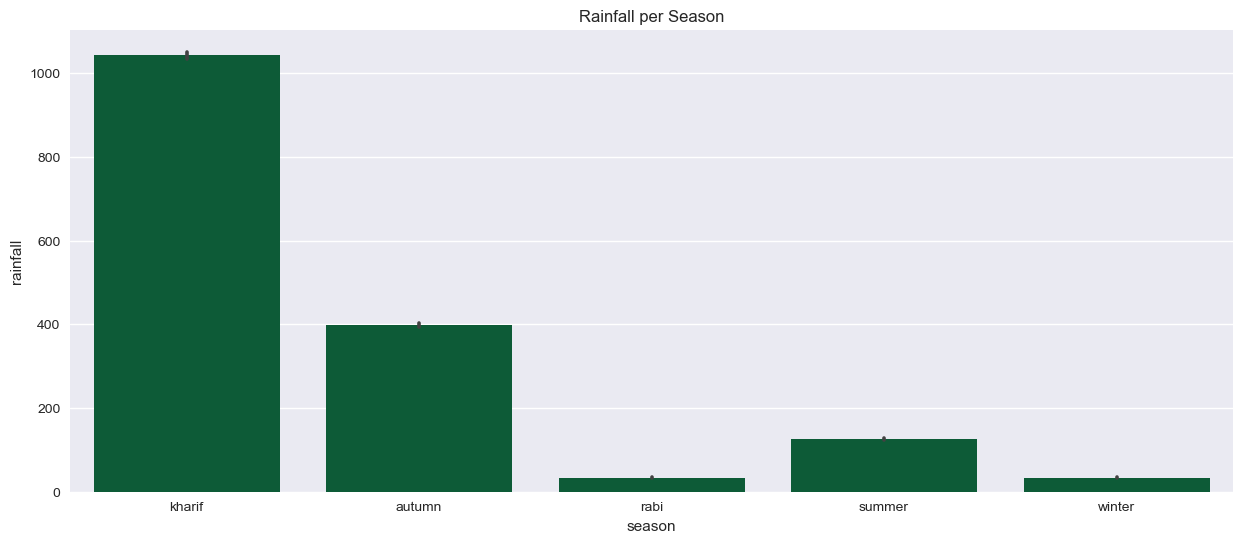

In [179]:
# Check rainfall amount for each season from the combined data
fig, ax = plt.subplots(figsize=(15, 6)) 
sns.barplot(x=production['season'], y=production['rainfall'], color=deep_green)\
.set(title='Rainfall per Season')
plt.show()

The season with the most rainfall is Kharif followed by Autumn, while the least rainfall is seen in the Winter and Rabi seasons

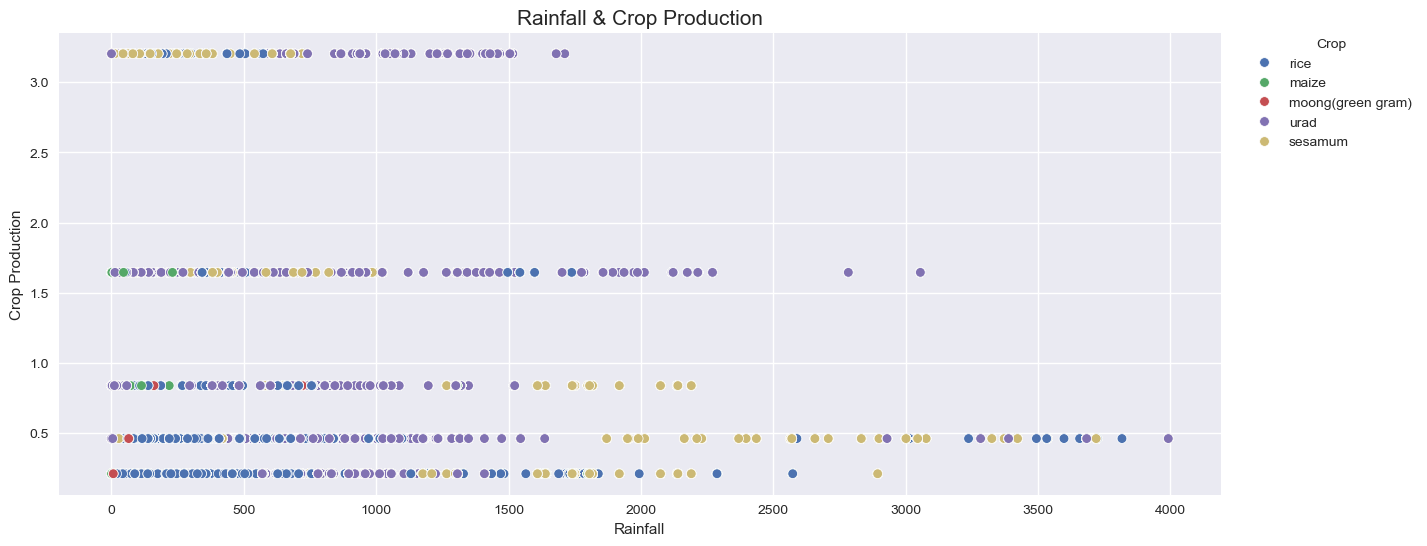

In [180]:
#Plotting rainfall and crop production
plt.figure(figsize=(15,6))
sns.scatterplot(data=production, x='rainfall',y='yields',hue='crop')
plt.title('Rainfall & Crop Production',size=15)
plt.xlabel('Rainfall')
plt.ylabel('Crop Production')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,title='Crop')
plt.ticklabel_format(style = 'plain')
plt.show()

We note that the values of rainfall and crop production are not strongly correlated  and that higheramounts of rainfall do not lead to higher production

## 3. Crop Modelling<a name="modelling"></a>

In [181]:
#import the necessary Machine learning libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
from sklearn.tree import DecisionTreeRegressor

In [182]:
# As year is a time variable, we will drop it for modelling
production = production.drop(['year'], axis=1)
production.head(1)

,state,season,crop,yields,rainfall
2,andaman and nicobar islands,kharif,rice,0.211834,1565.4


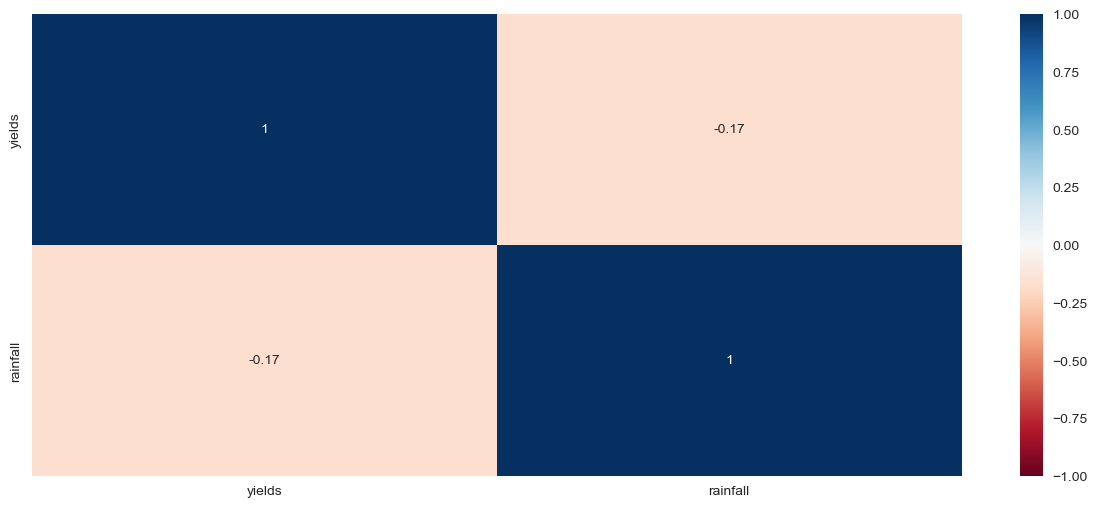

In [183]:
# To determine the relationship between the variables, 
# we will check the correlation using a heat map

# Select only numeric columns
numeric_data = production.select_dtypes(include='number')

# Show heatmap
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.show()

As the yields are not highly correlated with rainfall, we will use a machine learning model to incorporate the other categorical data to see what affects the yields.

In [184]:
# Converting categorical data into a form that can be used in machine learning
production_onehot = pd.get_dummies(production, columns=['state',"crop", "season"], prefix = ['state',"crop", "season"])
features=production_onehot.loc[:, production_onehot.columns != 'yields']
label=production['yields']
features.head(3)

,rainfall,state_andaman and nicobar islands,state_andhra pradesh,state_arunachal pradesh,state_assam and meghalaya,state_bihar,state_chhattisgarh,state_goa,state_gujarat,state_haryana delhi and chandigarh,...,crop_maize,crop_moong(green gram),crop_rice,crop_sesamum,crop_urad,season_autumn,season_kharif,season_rabi,season_summer,season_winter
2,1565.4,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
12,1783.0,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
18,1694.5,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [185]:
# Scale the features to a given range
scaler=MinMaxScaler()
features=scaler.fit_transform(features) 

In [186]:
# Split data into train and test
train_data, test_data, train_labels, test_labels = train_test_split(features, label, test_size=0.2, random_state=42)

In [187]:
# Set test data to columns that should be predicting. Yields is excluded as its the target variable
test_df=pd.DataFrame(test_data,columns=production_onehot.loc[:, production_onehot.columns != 'yields'].columns) 

ste=test_df[[col for col in test_df.columns if 'state' in col]].stack()[test_df[[col for col in test_df.columns if 'state' in col]].stack()>0]
stelist=list(pd.DataFrame(ste).index.get_level_values(1))
states=[i.split("_")[1] for i in stelist]
crp=test_df[[col for col in test_df.columns if 'crop' in col]].stack()[test_df[[col for col in test_df.columns if 'crop' in col]].stack()>0]
crplist=list(pd.DataFrame(crp).index.get_level_values(1))
crops=[i.split("_")[1] for i in crplist]
ses=test_df[[col for col in test_df.columns if 'season' in col]].stack()[test_df[[col for col in test_df.columns if 'season' in col]].stack()>0]
seslist=list(pd.DataFrame(ses).index.get_level_values(1))
seasons=[i.split("_")[1] for i in seslist]

In [188]:
test_df.head(3) #View the top 3 rows   

,rainfall,state_andaman and nicobar islands,state_andhra pradesh,state_arunachal pradesh,state_assam and meghalaya,state_bihar,state_chhattisgarh,state_goa,state_gujarat,state_haryana delhi and chandigarh,...,crop_maize,crop_moong(green gram),crop_rice,crop_sesamum,crop_urad,season_autumn,season_kharif,season_rabi,season_summer,season_winter
0,0.004809,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.127135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.211366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [189]:
# Drop the created dummy columns
test_df.drop([col for col in test_df.columns if 'state' in col],axis=1,inplace=True)
test_df.drop([col for col in test_df.columns if 'crop' in col],axis=1,inplace=True)
test_df.drop([col for col in test_df.columns if 'season' in col],axis=1,inplace=True)
test_df.head(3)

,rainfall
0,0.004809
1,0.127135
2,0.211366


In [190]:
# Return the categorical data we're using
test_df['state'] = states
test_df['crop'] = crops
test_df['season']=seasons
test_df.head(3)

,rainfall,state,crop,season
0,0.004809,uttar pradesh,rice,summer
1,0.127135,jammu and kashmir,moong(green gram),kharif
2,0.211366,maharashtra,sesamum,kharif


In [191]:
# Fitting a Decision tree regression model to the training data
clf=DecisionTreeRegressor()
model=clf.fit(train_data,train_labels)

# Predicting values for the test data
test_df["predicted_yields"]= model.predict(test_data)
test_df["actual_yields"]=pd.DataFrame(test_labels)["yields"].tolist()
test_group=test_df.groupby("crop")

**Model Accuracy**

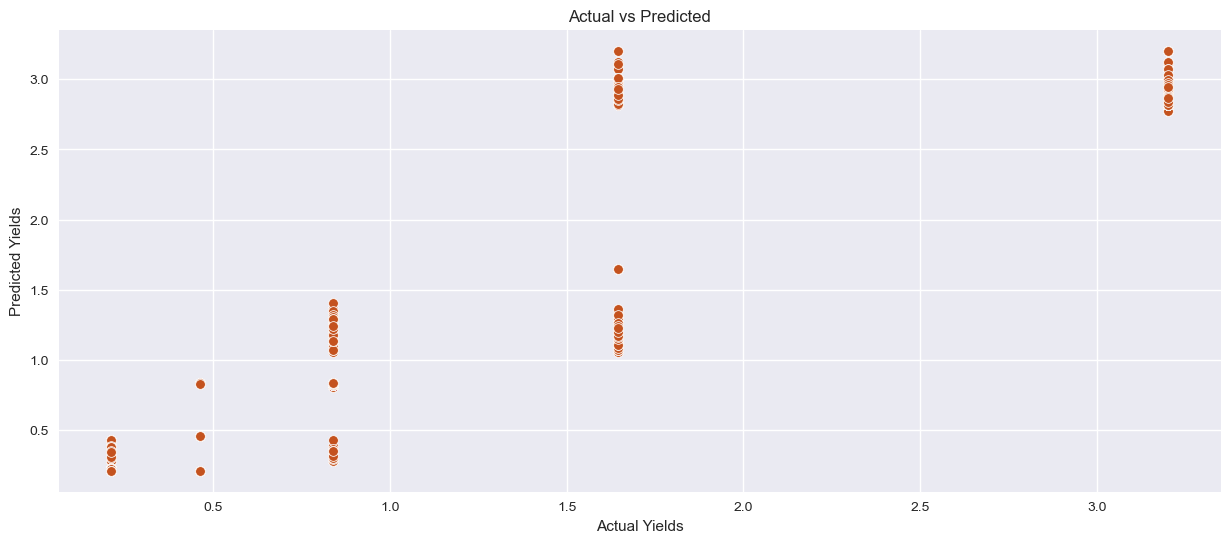

In [192]:
#Visualising the comparison between actual and predicted values
fig, ax = plt.subplots(figsize=(15, 6)) 

sns.scatterplot(data=test_df, x='actual_yields', y='predicted_yields',  
                color='#c4521e').set(xlabel='Actual Yields', ylabel='Predicted Yields', 
                                     title='Actual vs Predicted')
plt.show()

The model's predictions and actuals in the different bins look aligned. We'll use the MSE and RMSE to check the accuracy of our model.

In [193]:
# Coefficient of determination score
r2 = r2_score(test_df["actual_yields"], test_df["predicted_yields"])

# Model accuracy
mse = mean_squared_error(test_df["actual_yields"], test_df["predicted_yields"])
rmse = np.sqrt(mse)

print("R2 Score: {}".format(round(r2, 2)))
print("MSE: {}".format(round(mse, 2)))
print("RMSE: {}".format(round(rmse, 2)))

R2 Score: 0.93
MSE: 0.09
RMSE: 0.29


 ## 4. Visualization and Presentation<a name="vis2"></a>

In [194]:
# Create a copy of the model results
model_df = test_df.copy()

In [195]:
model_df['crop'].unique()# Check the unique crops in the model

array(['rice', 'moong(green gram)', 'sesamum', 'urad', 'maize'],
      dtype=object)

### 4.1. Predicted yields per season<a name="predictedyield"></a>

In [196]:
''' 
 To determine the planting calendar,
 we  apply the model to prdict the yield per season for the crops covered by the model
'''
# Group by seasons and crops
seasons_pred = model_df.groupby(['season', 'crop']).agg({'predicted_yields': 'mean'}).reset_index()

# Get yields for each crop per season
rice_seasons = seasons_pred.loc[seasons_pred['crop'] == 'rice'].sort_values('predicted_yields', ascending=False)
greengram_seasons = seasons_pred.loc[seasons_pred['crop'] == 'moong(green gram)'].sort_values('predicted_yields', ascending=False)
urad_seasons = seasons_pred.loc[seasons_pred['crop'] == 'urad'].sort_values('predicted_yields', ascending=False)
maize_seasons = seasons_pred.loc[seasons_pred['crop'] == 'maize'].sort_values('predicted_yields', ascending=False)
sesamum_seasons = seasons_pred.loc[seasons_pred['crop'] == 'sesamum'].sort_values('predicted_yields', ascending=False)

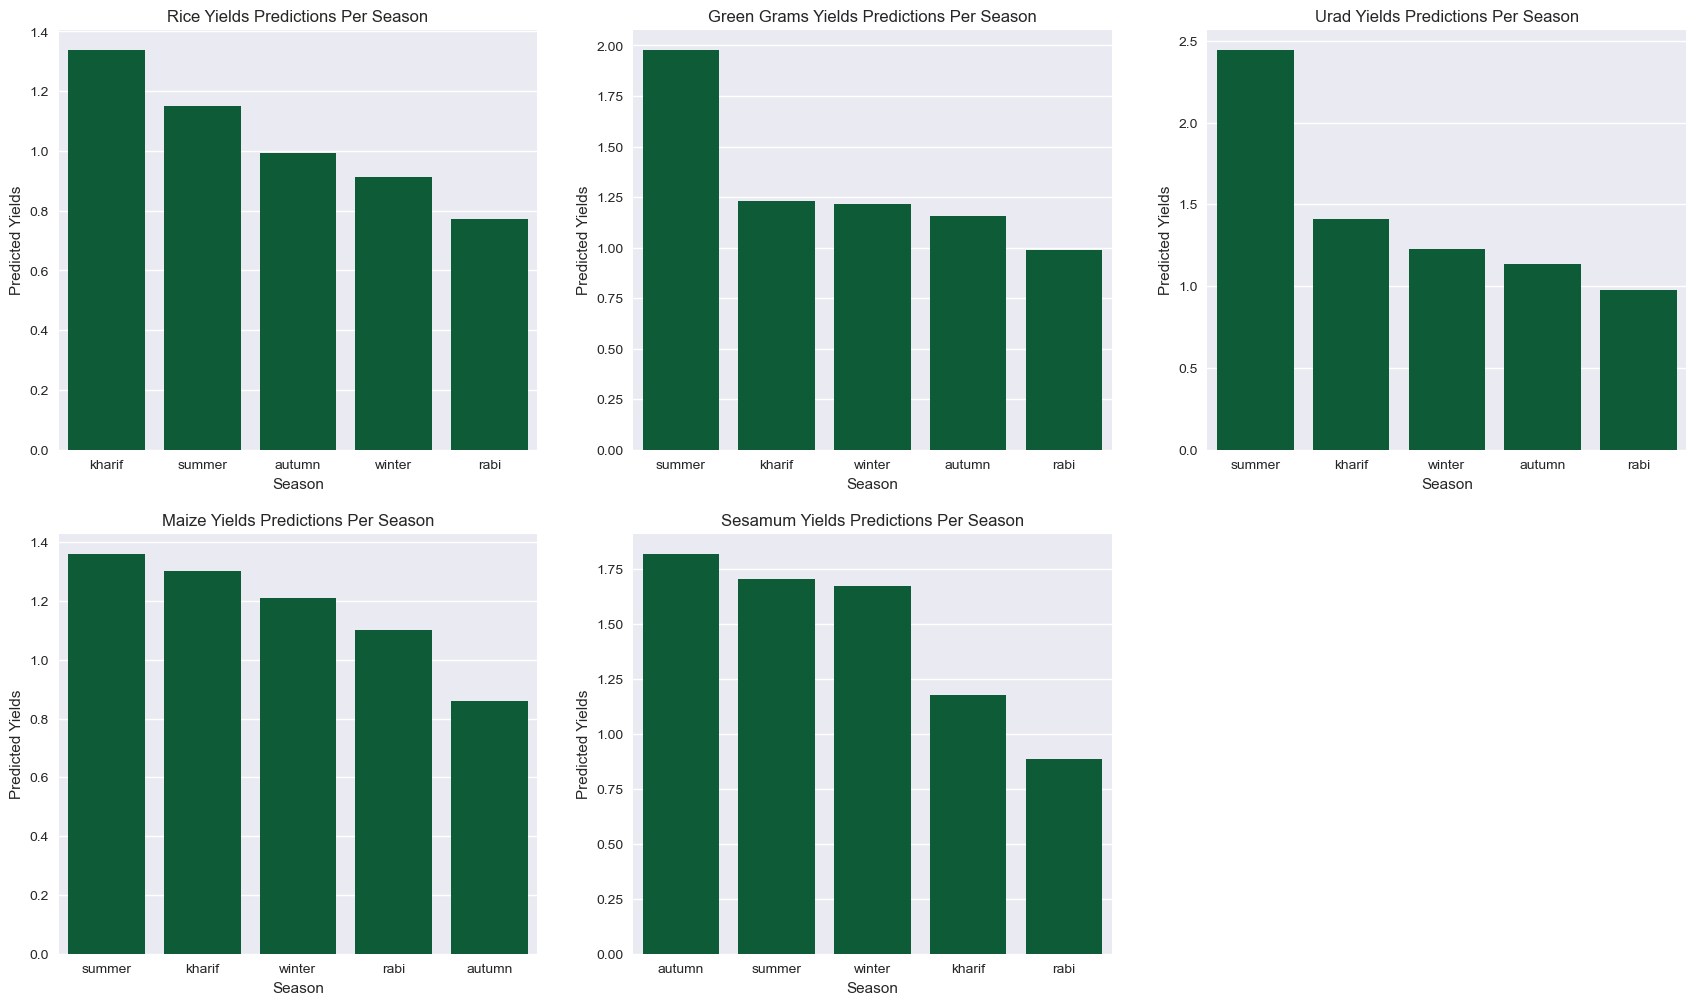

In [197]:
# Visualize the predictions for each crop per season
fig, ax =plt.subplots(2,3, figsize=(21, 12))

sns.barplot(data=rice_seasons, x='season', y='predicted_yields', ax=ax[0][0], color='#006838')\
.set(title='Rice Yields Predictions Per Season', xlabel='Season', ylabel='Predicted Yields')

sns.barplot(data=greengram_seasons, x='season', y='predicted_yields', ax=ax[0][1], color='#006838')\
.set(title='Green Grams Yields Predictions Per Season', xlabel='Season', ylabel='Predicted Yields')

sns.barplot(data=urad_seasons, x='season', y='predicted_yields', ax=ax[0][2], color='#006838')\
.set(title='Urad Yields Predictions Per Season', xlabel='Season', ylabel='Predicted Yields')

sns.barplot(data=maize_seasons, x='season', y='predicted_yields', ax=ax[1][0], color='#006838')\
.set(title='Maize Yields Predictions Per Season', xlabel='Season', ylabel='Predicted Yields')

sns.barplot(data=sesamum_seasons, x='season', y='predicted_yields', ax=ax[1][1], color='#006838')\
.set(title='Sesamum Yields Predictions Per Season', xlabel='Season', ylabel='Predicted Yields')

fig.delaxes(ax=ax[1][2])

plt.show()

### 4.2. Conclusion <a name="conclusion"></a>

**Conclusions Recommendations for Seasons**

From the predicted yields above; rice does well during the hharif season. Green grams, urad and maize do well during the summer season while sesamum does well duuring the autumn season. 

Maize also does well during kharif and sesamum during the summer.

**Crops Predicted Yields Per State**

In [198]:
''' 
 To localise the planting calendar,
 we  apply the model to prdict the yield per state for the crops covered by the model
'''

# Group by state and crops
states_pred = model_df.groupby(['state', 'crop']).agg({'predicted_yields': 'mean'}).reset_index()

# Get top 5 states for each crop
rice_states = states_pred.loc[states_pred['crop'] == 'rice']
rice_states = rice_states.nlargest(5, 'predicted_yields').sort_values('predicted_yields', ascending=False)

greengram_states = states_pred.loc[states_pred['crop'] == 'moong(green gram)']
greengram_states = greengram_states.nlargest(5, 'predicted_yields').sort_values('predicted_yields', ascending=False)

urad_states = states_pred.loc[states_pred['crop'] == 'urad']
urad_states = urad_states.nlargest(5, 'predicted_yields').sort_values('predicted_yields', ascending=False)

maize_states = states_pred.loc[states_pred['crop'] == 'maize']
maize_states = maize_states.nlargest(5, 'predicted_yields').sort_values('predicted_yields', ascending=False)

sesamum_states = states_pred.loc[states_pred['crop'] == 'sesamum']
sesamum_states = sesamum_states.nlargest(5, 'predicted_yields').sort_values('predicted_yields', ascending=False)

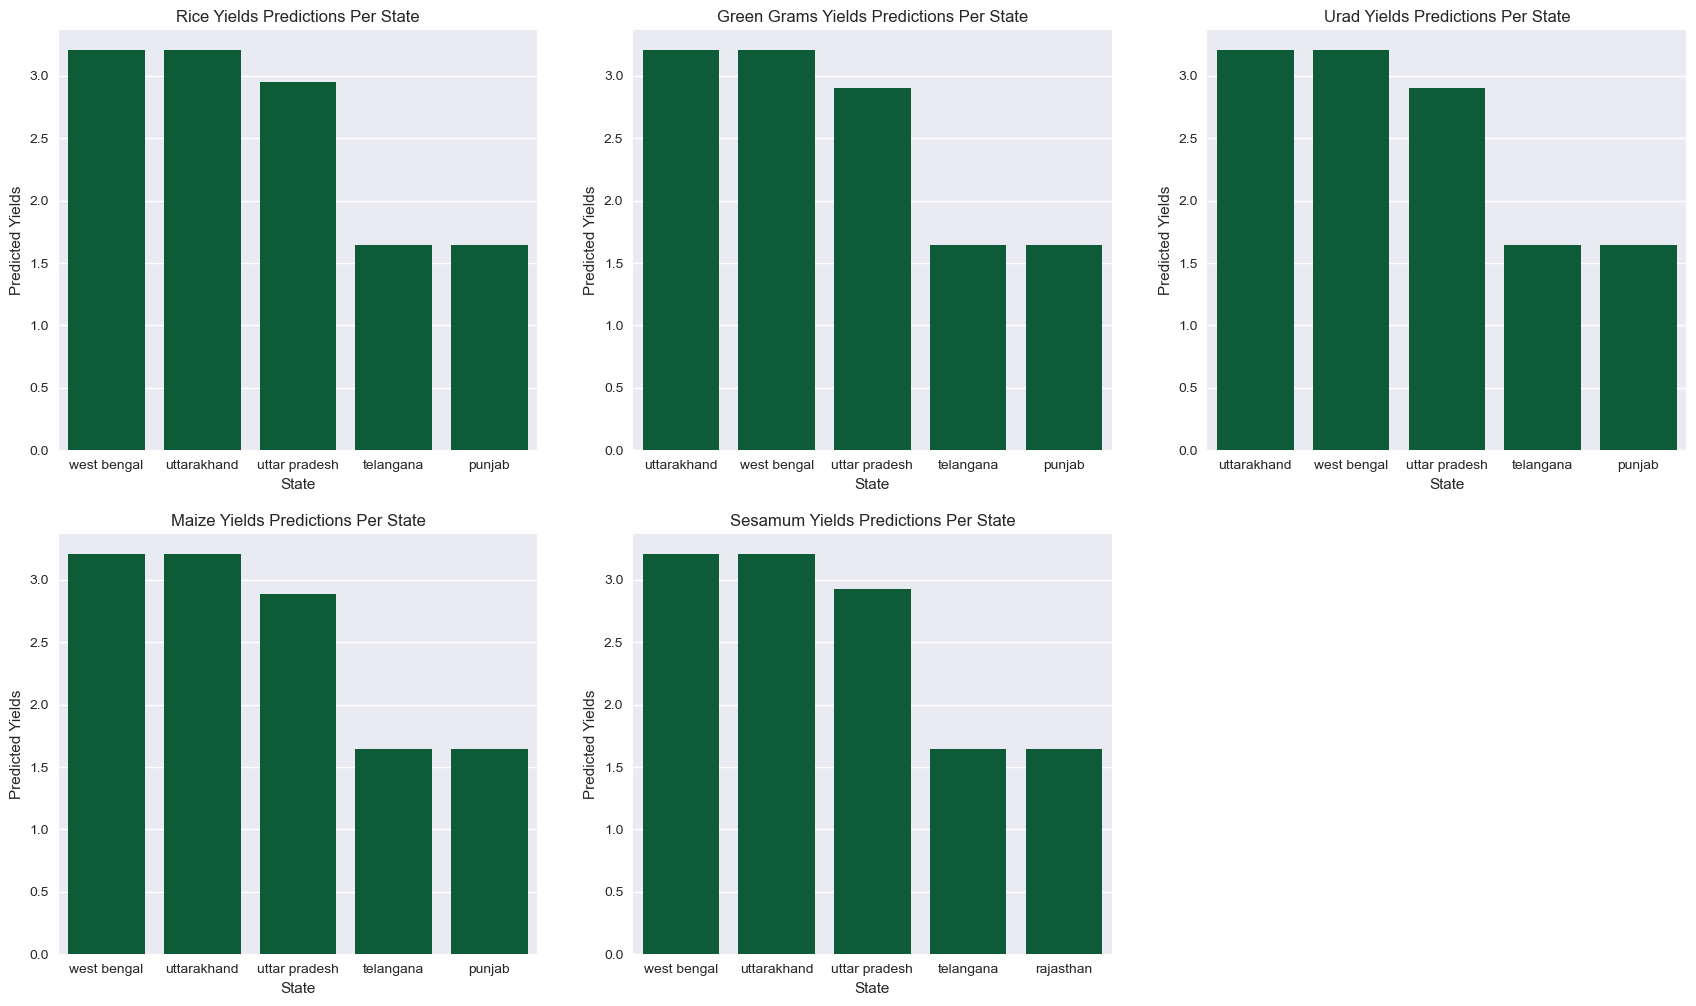

In [199]:
# Visualize the predictions for each crop per season
fig, ax =plt.subplots(2,3, figsize=(21, 12))

sns.barplot(data=rice_states, x='state', y='predicted_yields', ax=ax[0][0], color='#006838')\
.set(title='Rice Yields Predictions Per State', xlabel='State', ylabel='Predicted Yields')

sns.barplot(data=greengram_states, x='state', y='predicted_yields', ax=ax[0][1], color='#006838')\
.set(title='Green Grams Yields Predictions Per State', xlabel='State', ylabel='Predicted Yields')

sns.barplot(data=urad_states, x='state', y='predicted_yields', ax=ax[0][2], color='#006838')\
.set(title='Urad Yields Predictions Per State', xlabel='State', ylabel='Predicted Yields')

sns.barplot(data=maize_states, x='state', y='predicted_yields', ax=ax[1][0], color='#006838')\
.set(title='Maize Yields Predictions Per State', xlabel='State', ylabel='Predicted Yields')

sns.barplot(data=sesamum_states, x='state', y='predicted_yields', ax=ax[1][1], color='#006838')\
.set(title='Sesamum Yields Predictions Per State', xlabel='State', ylabel='Predicted Yields')

fig.delaxes(ax=ax[1][2])

plt.show()

The above plots represent the top 5 states which the respective crops will do well in. Farmers in these states will improve their yields further if they plant during the recommended seasons above.